# 🚀 TechNova Retail & Customer Churn Analysis
### Science in Code (SIC) Bootcamp — Day 5: Python, EDA & Logistic Regression

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8; background-color: #f8f9fa; padding: 16px; border-radius: 8px; border-right: 6px solid #2563eb;">

**أهلاً بكم في ورك شوب اليوم الخامس من كامب SIC لتحليل البيانات!** 📊

في هذا المشروع، سنقوم ببناء مسار تحليل وتنبؤ متكامل (End-to-End Pipeline) لشركة **TechNova**:
1. **استكشاف وفحص البيانات (Data Inspection)**: فحص أنواع الأعمدة وحجم البيانات والقيم المفقودة.
2. **تنظيف وتجهيز البيانات (Data Cleaning)**: معالجة القيم المفقودة، وتصحيح الأخطاء النصية، وحساب المبيعات والأرباح.
3. **التحليل الاستكشافي للبيانات (EDA)**: فهم سلوك الشراء ونسبة مغادرة العملاء (Churn) من خلال رسومات بيانية واضحة.
4. **هندسة الخصائص (Feature Engineering)**: تجميع البيانات على مستوى كل عميل (Customer Level).
5. **توحيد المقياس والتقسيم (StandardScaler & Train/Test Split)**: تجهيز البيانات لنموذج الانحدار اللوجستي.
6. **تدريب النموذج (Logistic Regression Training)**: تدريب نموذج Logistic Regression بدون أي تعقيد أو Hyperparameter Tuning.
7. **تقييم النموذج وتفسيره (Model Evaluation & Interpretability)**: حساب الدقة، مصفوفة الارتباك، ومنحنى ROC، وفهم أوزان الخصائص.
8. **حفظ النموذج (Model Persistence)**: حفظ الموديل والـ Scaler لاستخدامهما في تطبيق **Streamlit**.

</div>

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### 📦 الخطوة الأولى: استيراد المكتبات الأساسية (Importing Libraries)
سنقوم باستيراد المكتبات الضرورية:
- `pandas` & `numpy`: لمعالجة وتحليل البيانات وتجهيز المصفوفات.
- `matplotlib` & `seaborn`: لإنشاء الرسوم البيانية التفاعلية والجذابة.
- `scikit-learn`: لتقسيم البيانات (`train_test_split`)، وتوحيد المقاييس (`StandardScaler`)، و موديل `LogisticRegression`، ومقاييس الأداء.
- `joblib`: لحفظ النموذج المُدرّب وأداة التوحيد لاستخدامهما في تطبيق الويب.

</div>

In [ ]:
# ============================================================
# 1. IMPORTING ESSENTIAL LIBRARIES
# ============================================================
# pandas: For tabular data manipulation and aggregation
import pandas as pd

# numpy: For high-performance numerical and array operations
import numpy as np

# matplotlib & seaborn: For professional exploratory visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# os & json: For path management and metadata serialization
import os
import json
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings for clean output

# Scikit-Learn: Machine Learning components
from sklearn.model_selection import train_test_split  # Split data into training and testing subsets
from sklearn.preprocessing import StandardScaler      # Standardize features by removing the mean and scaling to unit variance
from sklearn.linear_model import LogisticRegression   # Linear model for binary classification (Active vs Churned)
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve) # Evaluation metrics

# joblib: Efficient serialization for Python objects and scikit-learn models
import joblib

# Set professional aesthetic configuration for all Matplotlib/Seaborn plots
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("✅ All required libraries imported successfully!")

✅ All required libraries imported successfully!


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### 📥 الخطوة الثانية: قراءة واستكشاف البيانات الأولية (Loading & Inspecting Data)
سنقرأ ملف البيانات `dataset_raw.csv` الموجود في مجلد `Datasets/`، ونفحص شكل البيانات، أنواع الأعمدة، ونسب القيم المفقودة لمعرفة المشاكل التي تحتاج إلى تنظيف.

</div>

In [ ]:
# ============================================================
# 2. LOAD RAW DATASET
# ============================================================

# Load the raw CSV into a pandas DataFrame
df_raw = pd.read_csv(r"C:\Users\MOHAMED TAMER\Desktop\SIC\SIC_Bootcamp_TechNova_Project\Datasets\dataset_raw.csv")

print(f"📊 Dataset Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")
print("📋 Dataset Summary Information:")
df_raw.info()

print("\n🔍 Missing Values per Column:")
missing_vals = df_raw.isnull().sum()
print(missing_vals[missing_vals > 0])

# Display the first 5 records
df_raw.head()

📊 Dataset Shape: 5,000 rows × 18 columns

📋 Dataset Summary Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             5000 non-null   int64  
 1   FullName               5000 non-null   object 
 2   Age                    5000 non-null   int64  
 3   City                   5000 non-null   object 
 4   JoinDate               5000 non-null   object 
 5   Churn                  5000 non-null   int64  
 6   OrderID                5000 non-null   int64  
 7   OrderDate              5000 non-null   object 
 8   ShipMode               5000 non-null   object 
 9   ProductID              5000 non-null   int64  
 10  ProductName            5000 non-null   object 
 11  Category               5000 non-null   object 
 12  Price                  5000 non-null   float64
 13  Cost                   4750 non-nul

,CustomerID,FullName,Age,City,JoinDate,Churn,OrderID,OrderDate,ShipMode,ProductID,ProductName,Category,Price,Cost,Quantity,Discount,Days_Since_Last_Order,Total_Orders
0,2126,CUSTOMER_0,35,Mansoura,02-08-2023,0,11420,02-08-2023,Same Day,135,Product_135,Home Appliances,712.82,334.36,1,NaN,518,4
1,2459,Customer_1,54,Cairo,08/16/2020,0,12597,08/16/2020,Express,119,Product_119,Home Appliances,148.60,76.56,2,0.05,661,6
2,1860,Customer_2,60,Mansoura,02/21/2020,1,10496,02/21/2020,Same Day,113,Product_113,Clothing,1039.74,640.86,1,0.05,1094,3
3,2294,Customer_3,17,Cairo,07/17/2021,0,12220,07/17/2021,Same Day,105,Product_105,Electronics,117.63,57.56,3,NaN,673,5
4,2130,Customer_4,32,Luxor,16-05-2021,0,10104,16-05-2021,Express,144,Product_144,Electronics,413.23,274.34,5,NaN,349,4


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### 🧹 الخطوة الثالثة: تنظيف ومعالجة البيانات (Data Cleaning & Preparation)
نقوم بمعالجة المشكلات المكتشفة في البيانات:
1. **التكلفة (`Cost`)**: ملء القيم المفقودة باستخدام القيمة الوسيطة (`median`).
2. **الخصم (`Discount`)**: ملء القيم المفقودة بالقيمة `0.0` (لا يوجد خصم).
3. **الفئات (`Category`)**: تصحيح الأخطاء الإملائية والاختصارات مثل `Elec` و `elect` إلى `Electronics`.
4. **أسماء العملاء (`FullName`)**: إزالة المسافات الزائدة وضبط حالة الأحرف لتكون منسقة (`Title Case`).
5. **حساب المبيعات الفعلية (`Revenue`)**: $\text{Price} \times \text{Quantity} \times (1 - \text{Discount})$
6. **حساب صافي الأرباح (`Profit`)**: $\text{Revenue} - (\text{Cost} \times \text{Quantity})$

</div>

In [ ]:
# ============================================================
# 3. DATA CLEANING & REVENUE/PROFIT CALCULATION
# ============================================================
# Create a working copy to preserve original raw data
df = df_raw.copy()

# 1. Fill missing Cost values with the median cost
df['Cost'] = df['Cost'].fillna(df['Cost'].median())

# 2. Fill missing Discount values with 0 (assuming full price paid)
df['Discount'] = df['Discount'].fillna(0.0)

# 3. Fix category typographical variations and abbreviations
df['Category'] = df['Category'].replace({
    'Elec': 'Electronics',
    'elect': 'Electronics'
})

# 4. Clean customer names: strip leading/trailing spaces and apply Title Case
df['FullName'] = df['FullName'].astype(str).str.strip().str.title()

# 5. Compute actual realized Revenue per line item
df['Revenue'] = df['Price'] * df['Quantity'] * (1.0 - df['Discount'])

# 6. Compute Net Profit generated per line item
df['Profit'] = df['Revenue'] - (df['Cost'] * df['Quantity'])

print("✅ Data Cleaning & Feature Calculations Completed!")
print(f"💰 Total Realized Revenue: ${df['Revenue'].sum():,.2f}")
print(f"📈 Total Net Profit:       ${df['Profit'].sum():,.2f}")
print(f"🏷️ Overall Profit Margin:  {(df['Profit'].sum() / df['Revenue'].sum()):.2%}")

df[['OrderID', 'FullName', 'Category', 'Price', 'Quantity', 'Discount', 'Revenue', 'Profit']].head()

✅ Data Cleaning & Feature Calculations Completed!
💰 Total Realized Revenue: $11,398,597.13
📈 Total Net Profit:       $4,869,126.86
🏷️ Overall Profit Margin:  42.72%


,OrderID,FullName,Category,Price,Quantity,Discount,Revenue,Profit
0,11420,Customer_0,Home Appliances,712.82,1,0.00,712.820,378.460
1,12597,Customer_1,Home Appliances,148.60,2,0.05,282.340,129.220
2,10496,Customer_2,Clothing,1039.74,1,0.05,987.753,346.893
3,12220,Customer_3,Electronics,117.63,3,0.00,352.890,180.210
4,10104,Customer_4,Electronics,413.23,5,0.00,2066.150,694.450


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### 📊 الخطوة الرابعة: التحليل الاستكشافي للبيانات (Exploratory Data Analysis - EDA)
سنقوم بإنشاء رسومات بيانية لاستخلاص الرؤى التجارية:
1. **نسبة الـ Churn الإجمالية**: ما هي نسبة العملاء المغادرين مقارنة بالعملاء النشطين؟
2. **المبيعات والأرباح حسب الفئة**: ما هي الفئات الأكثر ربحية؟
3. **حداثة آخر طلب (`Days_Since_Last_Order`)**: هل العملاء الذين لم يشتروا منذ فترة طويلة أكثر عرضة للمغادرة؟
4. **مصفوفة الارتباط (Correlation Heatmap)**: قياس العلاقات الخطية بين الخصائص الرقمية.

</div>

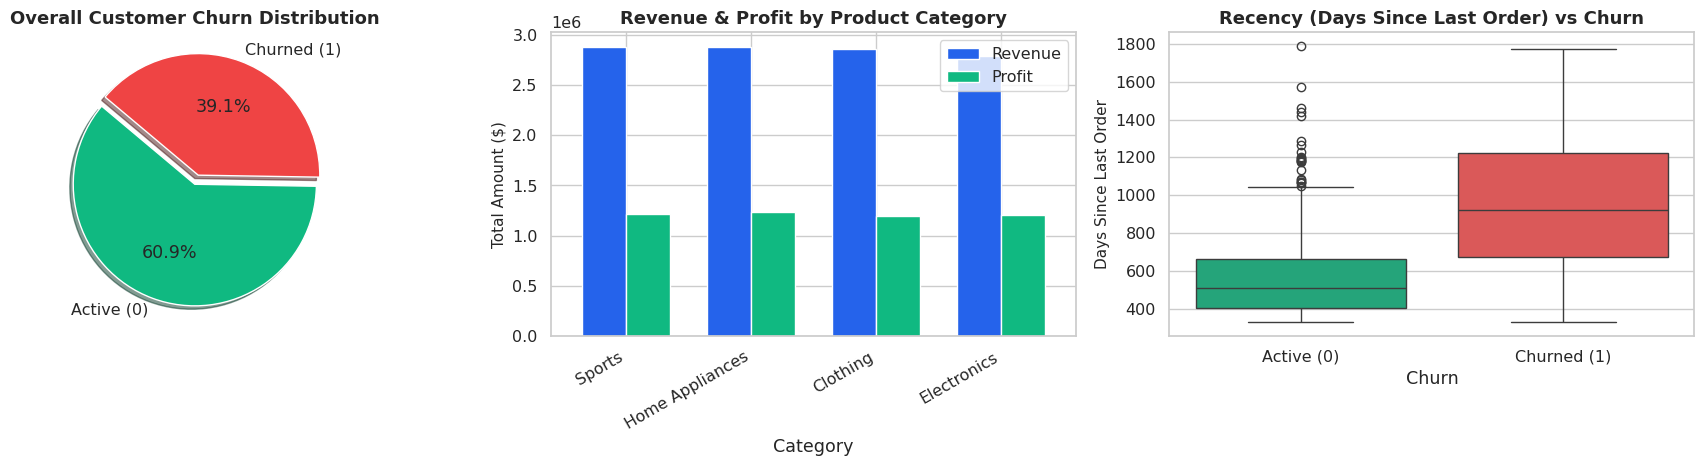

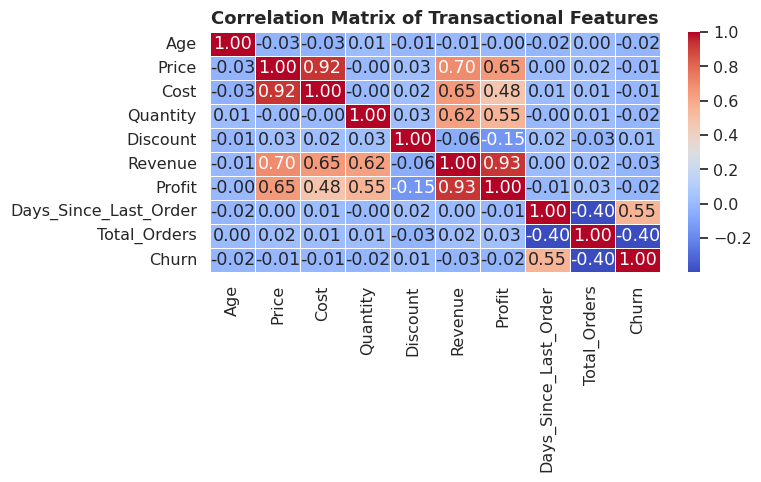

In [ ]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# Figure 1: Multi-panel business overview
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Customer Churn Ratio (Unique Customers)
customer_churn_summary = df.groupby('CustomerID')['Churn'].max().value_counts()
axes[0].pie(customer_churn_summary, labels=['Active (0)', 'Churned (1)'], autopct='%1.1f%%',
            colors=['#10b981', '#ef4444'], startangle=140, explode=(0, 0.08), shadow=True)
axes[0].set_title('Overall Customer Churn Distribution', fontsize=13, fontweight='bold')

# Plot 2: Revenue and Profit by Category
cat_financials = df.groupby('Category')[['Revenue', 'Profit']].sum().sort_values('Revenue', ascending=False)
cat_financials.plot(kind='bar', ax=axes[1], color=['#2563eb', '#10b981'], width=0.7)
axes[1].set_title('Revenue & Profit by Product Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Amount ($)', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend(['Revenue', 'Profit'])

# Plot 3: Recency vs Churn (Days Since Last Order)
recency_df = df.groupby('CustomerID').agg({'Days_Since_Last_Order': 'max', 'Churn': 'max'}).reset_index()
sns.boxplot(data=recency_df, x='Churn', y='Days_Since_Last_Order', palette=['#10b981', '#ef4444'], ax=axes[2])
axes[2].set_title('Recency (Days Since Last Order) vs Churn', fontsize=13, fontweight='bold')
axes[2].set_xticklabels(['Active (0)', 'Churned (1)'])
axes[2].set_ylabel('Days Since Last Order', fontsize=11)

plt.tight_layout()
plt.show()

# Figure 2: Correlation Heatmap
plt.figure(figsize=(8, 5))
numeric_cols = ['Age', 'Price', 'Cost', 'Quantity', 'Discount', 'Revenue', 'Profit', 'Days_Since_Last_Order', 'Total_Orders', 'Churn']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Correlation Matrix of Transactional Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### ⚙️ الخطوة الخامسة: هندسة الخصائص على مستوى العميل (Customer-Level Feature Engineering)
بما أن الهدف هو التنبؤ بمغادرة **العميل ككل** وليس طلب واحد، نقوم بتجميع بيانات الطلبات لكل عميل (`CustomerID`):
- `Age`: عمر العميل (مع استبدال القيم غير المنطقية الأقل من 18 أو الأكبر من 100 بالوسيط).
- `Total_Spent`: إجمالي المبالغ المنفقة خلال فترة التعامل (`sum`).
- `Days_Since_Last_Order`: عدد الأيام منذ آخر طلب (`max` - الحداثة).
- `Total_Orders`: إجمالي عدد الطلبات (`max` - التكرار).
- `Avg_Discount`: متوسط نسبة الخصم التي حصل عليها العميل (`mean`).
- `Avg_Profit`: متوسط الربح المحقق من العميل في كل طلب (`mean`).
- `Churn`: المتغير المستهدف (0 = عميل نشط، 1 = عميل غادر).

</div>

In [ ]:
# ============================================================
# 5. FEATURE ENGINEERING: CUSTOMER-LEVEL AGGREGATION
# ============================================================
# Group all transactions by CustomerID to create a profile per customer
customer_df = df.groupby('CustomerID').agg(
    Age=('Age', 'max'),                                      # Constant per customer
    Total_Spent=('Revenue', 'sum'),                          # Monetary value (Total lifetime spend)
    Days_Since_Last_Order=('Days_Since_Last_Order', 'max'),  # Recency value (Days since last order)
    Total_Orders=('Total_Orders', 'max'),                    # Frequency value (Total count of orders)
    Avg_Discount=('Discount', 'mean'),                       # Discount sensitivity
    Avg_Profit=('Profit', 'mean'),                           # Average profitability per order
    Churn=('Churn', 'max')                                   # Target variable (0 = Active, 1 = Churned)
).reset_index()

# Clean unrealistic Age values (<18 or >100) using median of realistic ages
median_valid_age = customer_df.loc[(customer_df['Age'] >= 18) & (customer_df['Age'] <= 100), 'Age'].median()
customer_df.loc[(customer_df['Age'] < 18) | (customer_df['Age'] > 100), 'Age'] = median_valid_age

print(f"✅ Aggregated dataset: {customer_df.shape[0]} unique customers")
print(f"🎯 Churn Class Balance: Active (0) = {(customer_df['Churn'] == 0).sum()} | Churned (1) = {(customer_df['Churn'] == 1).sum()}")
customer_df.head()

✅ Aggregated dataset: 1433 unique customers
🎯 Churn Class Balance: Active (0) = 872 | Churned (1) = 561


,CustomerID,Age,Total_Spent,Days_Since_Last_Order,Total_Orders,Avg_Discount,Avg_Profit,Churn
0,1000,67,7239.956,363,5,0.090000,751.098200,0
1,1001,54,13428.592,585,5,0.040000,1232.700400,0
2,1002,62,4097.643,687,4,0.075000,477.753250,1
3,1003,56,7844.480,446,2,0.000000,1584.840000,0
4,1004,55,1538.094,969,3,0.066667,241.514667,0


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### 🔀 الخطوة السادسة: تقسيم البيانات وتوحيد المقاييس (Train/Test Split & StandardScaler)
- **التقسيم (Train/Test Split)**: بنسبة 80% للتدريب و 20% للاختبار، مع خيار `stratify=y` للحفاظ على نفس نسبة الـ Churn في المجموعتين.
- **توحيد المقاييس (StandardScaler)**: طرح المتوسط وقسمته على الانحراف المعياري ($Z = \frac{X - \mu}{\sigma}$). نقوم بـ `fit_transform` على بيانات التدريب فقط، و `transform` على بيانات الاختبار لمنع تسريب البيانات (Data Leakage).

</div>

In [ ]:
# ============================================================
# 6. TRAIN/TEST SPLIT & FEATURE SCALING
# ============================================================
# Define feature matrix (X) and target vector (y)
feature_names = ['Age', 'Total_Spent', 'Days_Since_Last_Order', 'Total_Orders', 'Avg_Discount', 'Avg_Profit']
X = customer_df[feature_names]
y = customer_df['Churn']

# Split data: 80% for model training, 20% for unseen evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply StandardScaler to bring all features to mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit and transform training data
X_test_scaled = scaler.transform(X_test)         # Transform test data using training parameters

print(f"🔀 Training Set: {X_train.shape[0]} samples | Testing Set: {X_test.shape[0]} samples")
print(f"📊 Churn Ratio -> Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

🔀 Training Set: 1146 samples | Testing Set: 287 samples
📊 Churn Ratio -> Train: 39.18% | Test: 39.02%


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### 🤖 الخطوة السابعة: تدريب موديل الانحدار اللوجستي (Logistic Regression Training)
سنقوم بتدريب نموذج **Logistic Regression** المباشر:
- يستخدم دالة السيجمويد ($P = \frac{1}{1 + e^{-z}}$) لحساب احتمالية انضمام العميل لفئة المغادرين.
- تدريب نظيف ومباشر بدون أي Hyperparameter Tuning إضافي.

</div>

In [ ]:
# ============================================================
# 7. MODEL TRAINING: LOGISTIC REGRESSION
# ============================================================
# Initialize standard Logistic Regression model
# random_state=42: Ensures reproducible training results
# max_iter=500: Ensures full convergence during gradient optimization
model = LogisticRegression(random_state=42, max_iter=500)

# Train the model on scaled training features
model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression Model trained successfully!")
print(f"Intercept (Beta 0): {model.intercept_[0]:.4f}")
print("Learned Feature Coefficients:")
for feat, coef in zip(feature_names, model.coef_[0]):
    print(f"  - {feat:22s}: {coef:+.4f}")

✅ Logistic Regression Model trained successfully!
Intercept (Beta 0): -0.5288
Learned Feature Coefficients:
  - Age                   : +0.0382
  - Total_Spent           : -0.7271
  - Days_Since_Last_Order : +1.3790
  - Total_Orders          : -0.1764
  - Avg_Discount          : +0.0701
  - Avg_Profit            : +0.3936


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### 📈 الخطوة الثامنة: تقييم الموديل وتفسير النتائج (Model Evaluation & Interpretability)
سنقوم بتقييم النموذج على بيانات الاختبار التي لم يرها من قبل:
- **دقة النموذج (Accuracy)**: نسبة التوقعات الصحيحة الإجمالية.
- **مساحة ما تحت المنحنى (AUC-ROC)**: قدرة النموذج على التمييز بين العميل النشط والعميل المغادر.
- **مصفوفة الارتباك (Confusion Matrix)**: توضيح التوقعات الصحيحة والخاطئة.
- **أهمية الخصائص (Feature Weights)**: فهم أي الخصائص تزيد من احتمالية المغادرة وأيها يدعم بقاء العميل.

</div>

🎯 Test Accuracy:  81.88%
📈 AUC-ROC Score:  0.8815

📋 Detailed Classification Report:
              precision    recall  f1-score   support

  Active (0)       0.82      0.90      0.86       175
 Churned (1)       0.82      0.69      0.75       112

    accuracy                           0.82       287
   macro avg       0.82      0.80      0.80       287
weighted avg       0.82      0.82      0.82       287



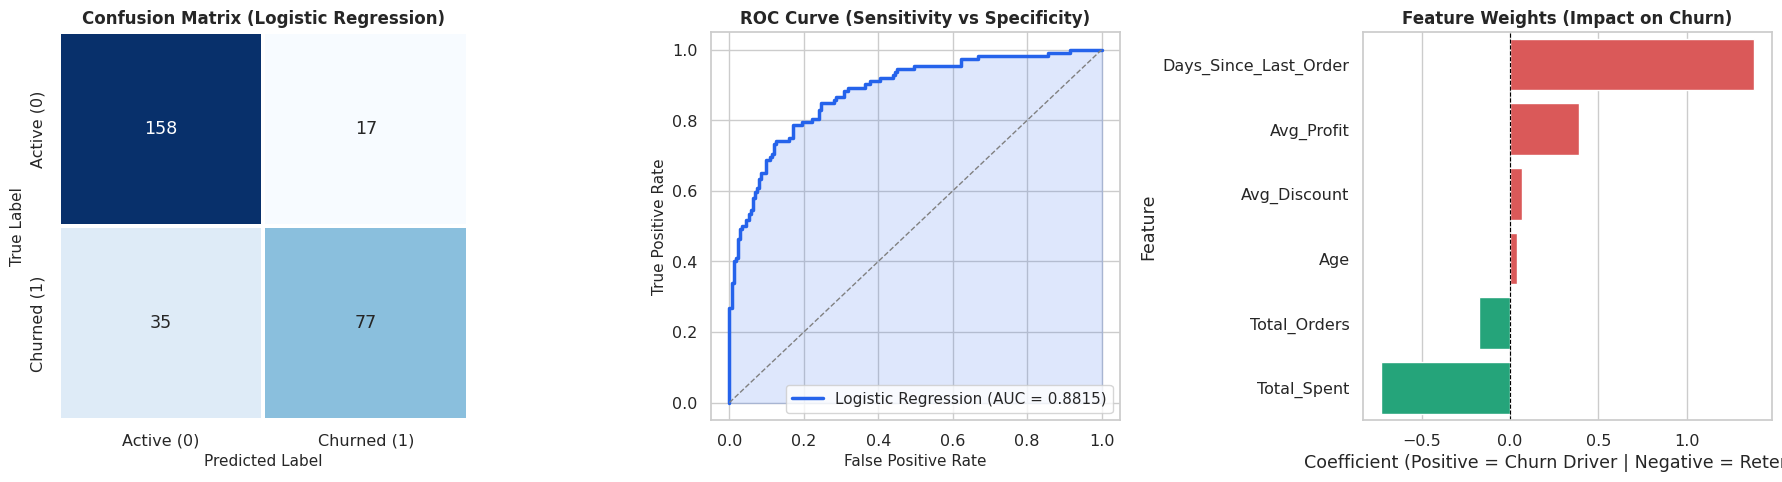

In [ ]:
# ============================================================
# 8. MODEL EVALUATION & INTERPRETABILITY
# ============================================================
# Predict binary labels (0 or 1) and continuous probabilities for test data
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)
test_cm = confusion_matrix(y_test, y_pred)

print(f"🎯 Test Accuracy:  {test_acc:.2%}")
print(f"📈 AUC-ROC Score:  {test_auc:.4f}")
print(f"\n📋 Detailed Classification Report:\n{classification_report(y_test, y_pred, target_names=['Active (0)', 'Churned (1)'])}")

# Visualizations: Confusion Matrix, ROC Curve, and Feature Weights
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active (0)', 'Churned (1)'], yticklabels=['Active (0)', 'Churned (1)'],
            cbar=False, linewidths=1.5, linecolor='white')
axes[0].set_title('Confusion Matrix (Logistic Regression)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2563eb', lw=2.5, label=f'Logistic Regression (AUC = {test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#2563eb')
axes[1].set_title('ROC Curve (Sensitivity vs Specificity)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(loc='lower right', fontsize=11)

# 3. Feature Coefficients Plot
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': model.coef_[0]
}).sort_values(by='Weight', ascending=False)

bar_colors = ['#ef4444' if w > 0 else '#10b981' for w in coef_df['Weight']]
sns.barplot(data=coef_df, x='Weight', y='Feature', palette=bar_colors, ax=axes[2])
axes[2].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Feature Weights (Impact on Churn)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Coefficient (Positive = Churn Driver | Negative = Retention)')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 1.8;">

### 💾 الخطوة التاسعة: حفظ النموذج وأداة التوحيد (Model Persistence)
نقوم بحفظ النموذج والـ Scaler والبيانات الوصفية في مجلد `models/`:
1. `models/churn_model.pkl`: النموذج المُدرّب.
2. `models/scaler.pkl`: أداة توحيد المقاييس (ضرورية جداً لتحويل أي مدخلات جديدة).
3. `models/model_metadata.json`: ملف JSON يحتوي على مواصفات الموديل والدقة وقائمة الخصائص.

**مبروك! اكتمل تدريب النموذج وأصبح جاهزاً للتشغيل الفوري عبر تطبيق Streamlit! 🚀**

</div>

In [ ]:
# ============================================================
# 9. SAVE MODEL, SCALER, AND METADATA
# ============================================================
# Ensure models directory exists
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# 1. Save Logistic Regression Model
model_save_path = os.path.join(models_dir, 'churn_model.pkl')
joblib.dump(model, model_save_path)
print(f"✅ Model saved successfully to:  {model_save_path}")

# 2. Save StandardScaler
scaler_save_path = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_save_path)
print(f"✅ Scaler saved successfully to: {scaler_save_path}")

# 3. Save Metadata JSON
metadata = {
    'model_name': 'Logistic Regression',
    'accuracy': float(test_acc),
    'auc_roc': float(test_auc),
    'features': feature_names,
    'intercept': float(model.intercept_[0]),
    'coefficients': {feat: float(c) for feat, c in zip(feature_names, model.coef_[0])}
}
meta_save_path = os.path.join(models_dir, 'model_metadata.json')
with open(meta_save_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4)
print(f"✅ Metadata saved to:            {meta_save_path}")

print("\n🚀 Everything is ready! You can now launch the Streamlit app:")
print("   streamlit run streamlit_app.py")

✅ Model saved successfully to:  models\churn_model.pkl
✅ Scaler saved successfully to: models\scaler.pkl
✅ Metadata saved to:            models\model_metadata.json

🚀 Everything is ready! You can now launch the Streamlit app:
   streamlit run streamlit_app.py
